In [1]:
%cd /content/drive/MyDrive/Colab Notebooks/ML_Prac/lesson5-augmentations



/content/drive/MyDrive/Colab Notebooks/ML_Prac/lesson5-augmentations


# AUGMENTATION_BASICS

utils

---



In [2]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms

def show_images(images, labels=None, nrow=8, title=None, size=128):
    """Визуализирует батч изображений."""
    images = images[:nrow]

    # Увеличиваем изображения до 128x128 для лучшей видимости
    resize_transform = transforms.Resize((size, size), antialias=True)
    images_resized = [resize_transform(img) for img in images]

    # Создаем сетку изображений
    fig, axes = plt.subplots(1, nrow, figsize=(nrow*2, 2))
    if nrow == 1:
        axes = [axes]

    for i, img in enumerate(images_resized):
        img_np = img.numpy().transpose(1, 2, 0)
        # Нормализуем для отображения
        img_np = np.clip(img_np, 0, 1)
        axes[i].imshow(img_np)
        axes[i].axis('off')
        if labels is not None:
            axes[i].set_title(f'Label: {labels[i]}')

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def show_single_augmentation(original_img, augmented_img, title="Аугментация"):
    """Визуализирует оригинальное и аугментированное изображение рядом."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # Увеличиваем изображения
    resize_transform = transforms.Resize((128, 128), antialias=True)
    orig_resized = resize_transform(original_img)
    aug_resized = resize_transform(augmented_img)

    # Оригинальное изображение
    orig_np = orig_resized.numpy().transpose(1, 2, 0)
    orig_np = np.clip(orig_np, 0, 1)
    ax1.imshow(orig_np)
    ax1.set_title("Оригинал")
    ax1.axis('off')

    # Аугментированное изображение
    aug_np = aug_resized.numpy().transpose(1, 2, 0)
    aug_np = np.clip(aug_np, 0, 1)
    ax2.imshow(aug_np)
    ax2.set_title(title)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

def show_multiple_augmentations(original_img, augmented_imgs, titles):
    """Визуализирует оригинальное изображение и несколько аугментаций."""
    n_augs = len(augmented_imgs)
    fig, axes = plt.subplots(1, n_augs + 1, figsize=((n_augs + 1) * 2, 2))

    # Увеличиваем изображения
    resize_transform = transforms.Resize((128, 128), antialias=True)
    orig_resized = resize_transform(original_img)

    # Оригинальное изображение
    orig_np = orig_resized.numpy().transpose(1, 2, 0)
    orig_np = np.clip(orig_np, 0, 1)
    axes[0].imshow(orig_np)
    axes[0].set_title("Оригинал")
    axes[0].axis('off')

    # Аугментированные изображения
    for i, (aug_img, title) in enumerate(zip(augmented_imgs, titles)):
        aug_resized = resize_transform(aug_img)
        aug_np = aug_resized.numpy().transpose(1, 2, 0)
        aug_np = np.clip(aug_np, 0, 1)
        axes[i + 1].imshow(aug_np)
        axes[i + 1].set_title(title)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

exta_augs

---



In [3]:
# @title
import torch
import random
import numpy as np
import cv2
from PIL import Image, ImageEnhance, ImageOps

class AddGaussianNoise:
    """Добавляет гауссов шум к изображению."""
    def __init__(self, mean=0., std=0.1):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

class RandomErasingCustom:
    """Случайно затирает прямоугольную область изображения."""
    def __init__(self, p=0.5, scale=(0.02, 0.2)):
        self.p = p
        self.scale = scale
    def __call__(self, img):
        if random.random() > self.p:
            return img
        c, h, w = img.shape
        area = h * w
        erase_area = random.uniform(*self.scale) * area
        erase_w = int(np.sqrt(erase_area))
        erase_h = int(erase_area // erase_w)
        x = random.randint(0, w - erase_w)
        y = random.randint(0, h - erase_h)
        img[:, y:y+erase_h, x:x+erase_w] = 0
        return img

class CutOut:
    """Вырезает случайную прямоугольную область из изображения."""
    def __init__(self, p=0.5, size=(16, 16)):
        self.p = p
        self.size = size
    def __call__(self, img):
        if random.random() > self.p:
            return img
        c, h, w = img.shape
        cut_h, cut_w = self.size
        x = random.randint(0, w - cut_w)
        y = random.randint(0, h - cut_h)
        img[:, y:y+cut_h, x:x+cut_w] = 0
        return img

class Solarize:
    """Инвертирует пиксели выше порога."""
    def __init__(self, threshold=128):
        self.threshold = threshold
    def __call__(self, img):
        img_np = img.numpy()
        mask = img_np > self.threshold / 255.0
        img_np[mask] = 1.0 - img_np[mask]
        return torch.from_numpy(img_np)

class Posterize:
    """Уменьшает количество бит на канал."""
    def __init__(self, bits=4):
        self.bits = bits
    def __call__(self, img):
        img_np = img.numpy()
        factor = 2 ** (8 - self.bits)
        img_np = (img_np * 255).astype(np.uint8)
        img_np = (img_np // factor) * factor
        return torch.from_numpy(img_np.astype(np.float32) / 255.0)

class AutoContrast:
    """Автоматически улучшает контраст изображения."""
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, img):
        if random.random() > self.p:
            return img
        img_np = img.numpy().transpose(1, 2, 0)
        img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
        img_pil = ImageOps.autocontrast(img_pil)
        img_np = np.array(img_pil).astype(np.float32) / 255.0
        return torch.from_numpy(img_np.transpose(2, 0, 1))

class ElasticTransform:
    """Эластичная деформация изображения."""
    def __init__(self, p=0.5, alpha=1, sigma=50):
        self.p = p
        self.alpha = alpha
        self.sigma = sigma
    def __call__(self, img):
        if random.random() > self.p:
            return img
        img_np = img.numpy().transpose(1, 2, 0)
        h, w = img_np.shape[:2]

        # Создаем случайные смещения
        dx = np.random.randn(h, w) * self.alpha
        dy = np.random.randn(h, w) * self.alpha

        # Сглаживаем смещения
        dx = cv2.GaussianBlur(dx, (0, 0), self.sigma)
        dy = cv2.GaussianBlur(dy, (0, 0), self.sigma)

        # Применяем деформацию
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        x = x + dx
        y = y + dy

        # Нормализуем координаты
        x = np.clip(x, 0, w - 1)
        y = np.clip(y, 0, h - 1)

        # Применяем трансформацию
        img_deformed = cv2.remap(img_np, x.astype(np.float32), y.astype(np.float32),
                                cv2.INTER_LINEAR)
        return torch.from_numpy(img_deformed.transpose(2, 0, 1))

class MixUp:
    """Смешивает два изображения."""
    def __init__(self, p=0.5, alpha=0.2):
        self.p = p
        self.alpha = alpha
    def __call__(self, img1, img2):
        if random.random() > self.p:
            return img1
        lam = np.random.beta(self.alpha, self.alpha)
        return lam * img1 + (1 - lam) * img2

datasets

---



In [4]:
# @title
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class CustomImageDataset(Dataset):
    """Кастомный датасет для работы с папками классов"""

    def __init__(self, root_dir, transform=None, target_size=(224, 224)):
        """
        Args:
            root_dir (str): Путь к папке с классами
            transform: Аугментации для изображений
            target_size (tuple): Размер для ресайза изображений
        """
        self.root_dir = root_dir
        self.transform = transform
        self.target_size = target_size

        # Получаем список классов (папок)
        self.classes = sorted([d for d in os.listdir(root_dir)
                              if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        # Собираем все пути к изображениям
        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    img_path = os.path.join(class_dir, img_name)
                    self.images.append(img_path)
                    self.labels.append(class_idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Загружаем изображение
        image = Image.open(img_path).convert('RGB')

        # Ресайзим изображение
        image = image.resize(self.target_size, Image.Resampling.LANCZOS)

        # Применяем аугментации
        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_names(self):
        """Возвращает список имен классов"""
        return self.classes

example

---



Оригинальное изображение, класс: Гароу

=== Демонстрация отдельных аугментаций ===


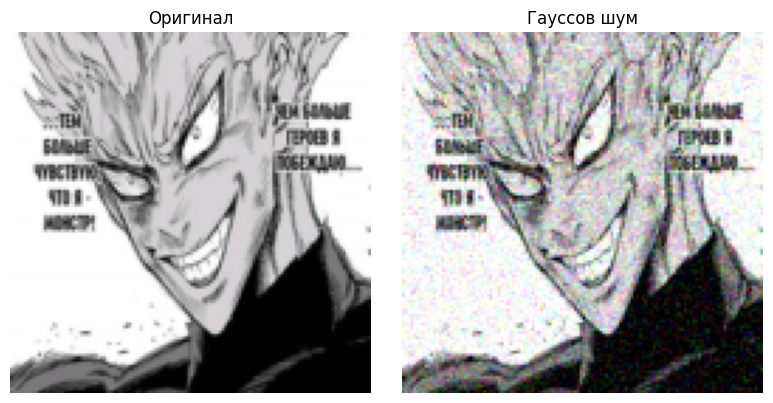

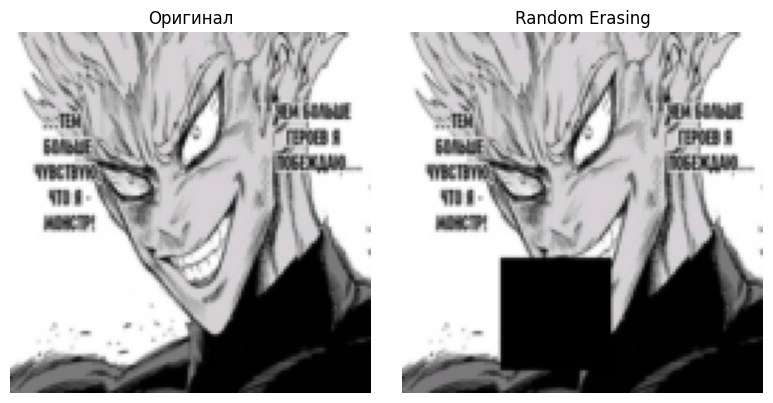

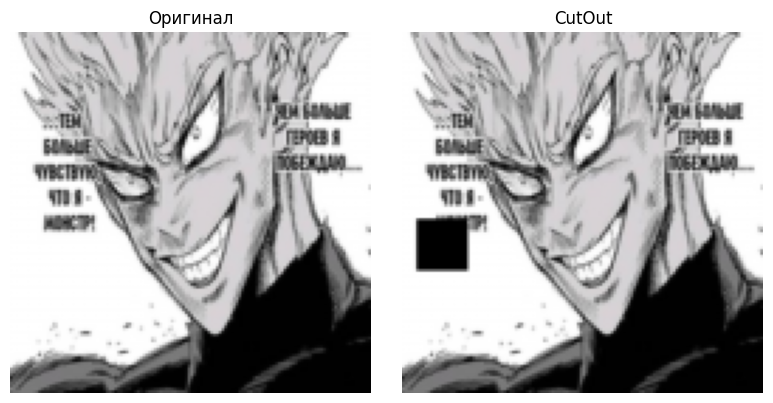

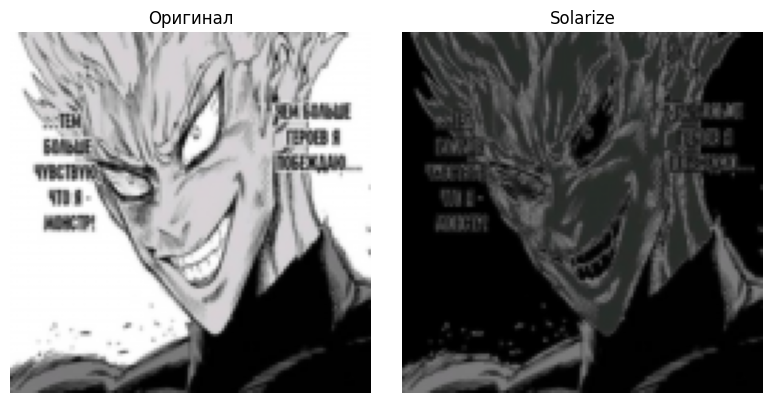

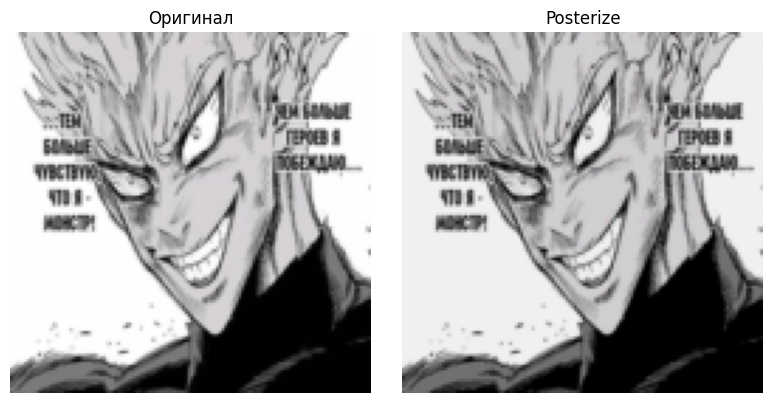

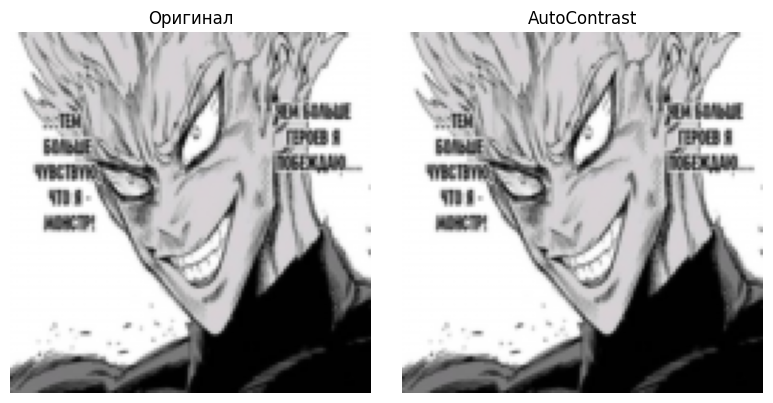

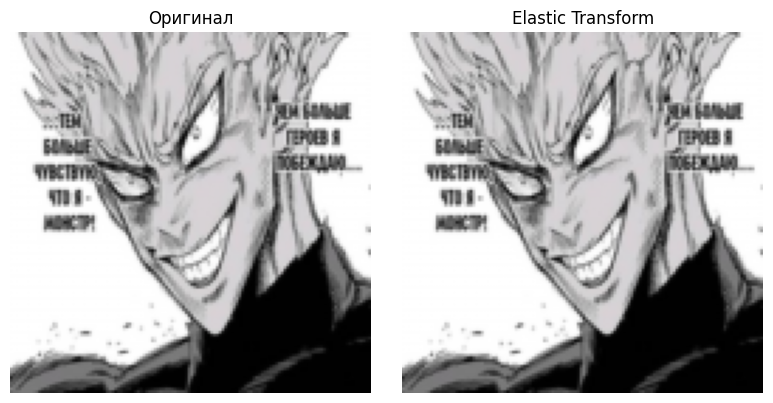


=== Стандартные аугментации torchvision ===


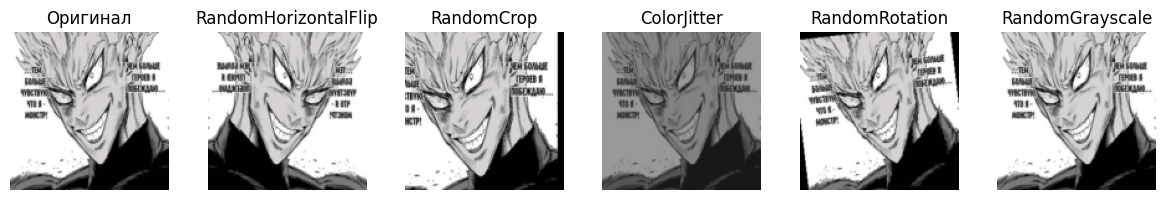


=== Комбинированные аугментации ===


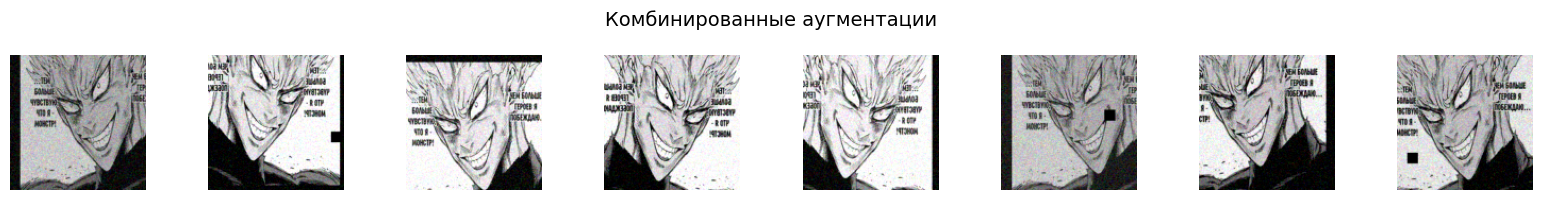

In [5]:
import torch
from torchvision import transforms
from PIL import Image


root = 'data/train'
dataset = CustomImageDataset(root, transform=None, target_size=(224, 224))

# Берем одно изображение для демонстрации (оно в формате PIL Image)
original_pil_img, label = dataset[0]
class_names = dataset.get_class_names()
print(f"Оригинальное изображение, класс: {class_names[label]}")

# !!! ВАЖНО: Делаем тензорную версию оригинальной картинки для отрисовки !!!
to_tensor = transforms.ToTensor()
original_tensor = to_tensor(original_pil_img)

# Демонстрация каждой аугментации отдельно
print("\n=== Демонстрация отдельных аугментаций ===")

# 1. Гауссов шум
noise_aug = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.2)
])
noise_img = noise_aug(original_pil_img)
show_single_augmentation(original_tensor, noise_img, "Гауссов шум")

# 2. Random Erasing
erase_aug = transforms.Compose([
    transforms.ToTensor(),
    RandomErasingCustom(p=1.0)
])
erase_img = erase_aug(original_pil_img)
show_single_augmentation(original_tensor, erase_img, "Random Erasing")

# 3. CutOut
cutout_aug = transforms.Compose([
    transforms.ToTensor(),
    CutOut(p=1.0, size=(32, 32))
])
cutout_img = cutout_aug(original_pil_img)
show_single_augmentation(original_tensor, cutout_img, "CutOut")

# 4. Solarize
solarize_aug = transforms.Compose([
    transforms.ToTensor(),
    Solarize(threshold=128)
])
solarize_img = solarize_aug(original_pil_img)
show_single_augmentation(original_tensor, solarize_img, "Solarize")

# 5. Posterize
posterize_aug = transforms.Compose([
    transforms.ToTensor(),
    Posterize(bits=4)
])
posterize_img = posterize_aug(original_pil_img)
show_single_augmentation(original_tensor, posterize_img, "Posterize")

# 6. AutoContrast
autocontrast_aug = transforms.Compose([
    transforms.ToTensor(),
    AutoContrast(p=1.0)
])
autocontrast_img = autocontrast_aug(original_pil_img)
show_single_augmentation(original_tensor, autocontrast_img, "AutoContrast")

# 7. Elastic Transform
elastic_aug = transforms.Compose([
    transforms.ToTensor(),
    ElasticTransform(p=1.0, alpha=1, sigma=50)
])
elastic_img = elastic_aug(original_pil_img)
show_single_augmentation(original_tensor, elastic_img, "Elastic Transform")

# Демонстрация стандартных аугментаций torchvision
print("\n=== Стандартные аугментации torchvision ===")

standard_augs = [
    ("RandomHorizontalFlip", transforms.RandomHorizontalFlip(p=1.0)),
    ("RandomCrop", transforms.RandomCrop(200, padding=20)),
    ("ColorJitter", transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)),
    ("RandomRotation", transforms.RandomRotation(degrees=30)),
    ("RandomGrayscale", transforms.RandomGrayscale(p=1.0))
]

augmented_imgs = []
titles = []

for name, aug in standard_augs:
    aug_transform = transforms.Compose([
        aug,
        transforms.ToTensor()
    ])
    aug_img = aug_transform(original_pil_img)
    augmented_imgs.append(aug_img)
    titles.append(name)

show_multiple_augmentations(original_tensor, augmented_imgs, titles)

# Демонстрация комбинированных аугментаций
print("\n=== Комбинированные аугментации ===")

combined_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(200, padding=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.1),
    CutOut(p=0.5)
])

combined_imgs = []
for i in range(8):
    combined_img = combined_aug(original_pil_img)
    combined_imgs.append(combined_img)

show_images(combined_imgs, title="Комбинированные аугментации")

# Папка Utils

---



In [6]:
import random
from PIL import Image, ImageEnhance, ImageFilter

class CustomRandomBlur:
    """Кастомное случайное размытие (Blur)."""
    def __init__(self, p=0.5, radius=(1, 3)):
        self.p = p
        self.radius = radius

    def __call__(self, img):
        if random.random() < self.p:
            r = random.uniform(*self.radius)
            return img.filter(ImageFilter.GaussianBlur(r))
        return img

class CustomColorJitter:
    """Кастомное изменение яркости и контраста."""
    def __init__(self, p=0.5, brightness=1.5, contrast=1.5):
        self.p = p
        self.brightness = brightness
        self.contrast = contrast

    def __call__(self, img):
        if random.random() < self.p:
            # Вычисляем случайный фактор: 1.0 - это оригинал
            b_factor = random.uniform(max(0, 1 - self.brightness/2), 1 + self.brightness/2)
            c_factor = random.uniform(max(0, 1 - self.contrast/2), 1 + self.contrast/2)
            img = ImageEnhance.Brightness(img).enhance(b_factor)
            img = ImageEnhance.Contrast(img).enhance(c_factor)
        return img

class CustomPixelate:
    """Кастомная пикселизация (уменьшение и увеличение размера без сглаживания)."""
    def __init__(self, p=0.5, pixel_size=4):
        self.p = p
        self.pixel_size = pixel_size

    def __call__(self, img):
        if random.random() < self.p:
            w, h = img.size
            # Уменьшаем (сжимаем)
            img_small = img.resize((w // self.pixel_size, h // self.pixel_size), Image.NEAREST)
            # Растягиваем обратно без сглаживания
            img = img_small.resize((w, h), Image.NEAREST)
        return img

In [7]:
import matplotlib.pyplot as plt
import os
from torchvision import transforms

def save_augmentation_grid(original_imgs, aug_dict, filename):
    """
    Создает сетку изображений: Оригинал + Все аугментации в ряд.
    original_imgs: список из PIL Images.
    aug_dict: словарь {"Название аугментации": [список измененных картинок]}.
    """
    n_rows = len(original_imgs)
    n_cols = 1 + len(aug_dict)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))

    # Защита от случая, когда n_rows = 1 (axes становится 1D массивом)
    if n_rows == 1:
        axes = [axes]

    for r in range(n_rows):
        # Отрисовка оригинала в первом столбце
        axes[r][0].imshow(original_imgs[r])
        if r == 0:
            axes[r][0].set_title("Original", fontsize=14, fontweight='bold')
        axes[r][0].axis('off')

        # Отрисовка аугментаций в следующих столбцах
        for c, (aug_name, aug_imgs) in enumerate(aug_dict.items(), start=1):
            axes[r][c].imshow(aug_imgs[r])
            if r == 0:
                axes[r][c].set_title(aug_name, fontsize=14)
            axes[r][c].axis('off')

    plt.tight_layout()

    # Сохраняем в папку results
    os.makedirs('homework5/results', exist_ok=True)
    path = os.path.join('homework5/results', filename)
    plt.savefig(path, bbox_inches='tight')
    plt.close()
    print(f"[*] График аугментаций сохранен: {path}")

# Задание 1

---



In [8]:
import os
import sys
import random
from torchvision import transforms

if os.path.exists('augmentations_basics'):
    sys.path.insert(0, 'augmentations_basics')
sys.path.insert(0, 'homework5')

def get_five_random_images(dataset):
    """Выбирает 5 случайных изображений из разных классов."""
    # Группируем индексы по классам
    class_indices = {}
    for idx, label in enumerate(dataset.labels):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(idx)

    # Выбираем до 5 случайных классов
    selected_classes = random.sample(list(class_indices.keys()), min(5, len(class_indices)))

    selected_images = []
    for cls in selected_classes:
        idx = random.choice(class_indices[cls])
        img, _ = dataset[idx]
        selected_images.append(img)

    return selected_images

def run_standard_augmentations():

    root_dir = 'data/train'
    if not os.path.exists(root_dir):
        print(f"Ошибка: папка {root_dir} не найдена.")
        return

    # Загружаем датасет (без аугментаций на этапе загрузки)
    dataset = CustomImageDataset(root_dir, transform=None, target_size=(224, 224))
    original_imgs = get_five_random_images(dataset)

    print(f"Отобрано {len(original_imgs)} изображений для тестирования.")

    # Стандартные аугментации torchvision
    standard_augs = {
        "H-Flip": transforms.RandomHorizontalFlip(p=1.0),
        "RandomCrop": transforms.RandomCrop(180, padding=20),
        "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5),
        "Rotation (30)": transforms.RandomRotation(degrees=30),
        "Grayscale": transforms.RandomGrayscale(p=1.0)
    }

    combined_standard = transforms.Compose(list(standard_augs.values()))
    standard_augs["Combined Standard"] = combined_standard

    standard_results = {}
    for name, aug in standard_augs.items():
        standard_results[name] = [aug(img) for img in original_imgs]

    save_augmentation_grid(original_imgs, standard_results, 'task1_standard_augs.png')

if __name__ == '__main__':
    run_standard_augmentations()

Отобрано 5 изображений для тестирования.
[*] График аугментаций сохранен: homework5/results/task1_standard_augs.png


# Задание 2

---



In [9]:
import os
import sys
import random

if os.path.exists('augmentations_basics'):
    sys.path.insert(0, 'augmentations_basics')
sys.path.insert(0, 'homework5')


def get_five_random_images(dataset):
    """Выбирает 5 случайных изображений из разных классов."""
    class_indices = {}
    for idx, label in enumerate(dataset.labels):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(idx)

    selected_classes = random.sample(list(class_indices.keys()), min(5, len(class_indices)))

    selected_images = []
    for cls in selected_classes:
        idx = random.choice(class_indices[cls])
        img, _ = dataset[idx]
        selected_images.append(img)

    return selected_images

def run_custom_augmentations():
    print("=== Задание 2: Кастомные Аугментации ===")

    root_dir = 'data/train'
    if not os.path.exists(root_dir):
        print(f"Ошибка: папка {root_dir} не найдена. Убедитесь, что датасет распакован.")
        return

    dataset = CustomImageDataset(root_dir, transform=None, target_size=(224, 224))
    original_imgs = get_five_random_images(dataset)

    print(f"Отобрано {len(original_imgs)} изображений для тестирования.")

    # Кастомные аугментации
    custom_augs = {
        "Custom Blur": CustomRandomBlur(p=1.0, radius=(2, 5)),
        "Custom Color": CustomColorJitter(p=1.0, brightness=2.0, contrast=2.0),
        "Custom Pixelate": CustomPixelate(p=1.0, pixel_size=8)
    }

    custom_results = {}
    for name, aug in custom_augs.items():
        custom_results[name] = [aug(img) for img in original_imgs]

    save_augmentation_grid(original_imgs, custom_results, 'task2_custom_augs.png')

if __name__ == '__main__':
    run_custom_augmentations()

=== Задание 2: Кастомные Аугментации ===
Отобрано 5 изображений для тестирования.
[*] График аугментаций сохранен: homework5/results/task2_custom_augs.png


# Задание 3

---



In [11]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

def analyze_dataset(root_dir):
    print(f"\n=== Задание 3: Анализ датасета ({root_dir}) ===")
    if not os.path.exists(root_dir):
        print(f"[!] Папка {root_dir} не найдена!")
        return

    class_counts = {}
    class_areas = {}
    widths = []
    heights = []

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path): continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)
        class_areas[class_name] = []

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    class_areas[class_name].append(w * h)
            except Exception as e:
                print(f"Ошибка чтения {img_path}: {e}")

    # Вывод статистики в консоль
    print("\n--- Количество изображений по классам ---")
    for cls, count in sorted(class_counts.items(), key=lambda item: item[1], reverse=True):
        print(f" - {cls}: {count}")

    print(f"\nВсего валидных изображений: {len(widths)}")
    if widths:
        print(f"Мин. размер: {min(widths)}x{min(heights)} px")
        print(f"Макс. размер: {max(widths)}x{max(heights)} px")
        print(f"Средний размер: {int(np.mean(widths))}x{int(np.mean(heights))} px")

    # Визуализация: Гистограммы площадей по каждому классу
    os.makedirs('homework5/results', exist_ok=True)

    for class_name, areas in class_areas.items():
        if not areas: continue

        plt.figure(figsize=(10, 6))
        n, bins, patches = plt.hist(areas, bins=10, color='red', edgecolor='black')

        plt.title(f'Распределение площади по классу "{class_name}"')
        plt.xlabel('Площадь (пиксели²)')
        plt.ylabel('Количество изображений')

        plt.grid(True, alpha=0.3)

        plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(f'homework5/results/task3_area_hist_{class_name}.png')
        plt.close()

    print(f"\n[*] Сгенерировано {len(class_areas)} гистограмм площадей по классам.")

    # Визуализация: Scatter plot размеров
    os.makedirs('homework5/results', exist_ok=True)

    plt.figure(figsize=(10, 6))
    plt.bar(class_counts.keys(), class_counts.values(), color='mediumpurple')
    plt.title('Распределение изображений по классам (Train)')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Количество')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('homework5/results/task3_class_distribution.png')
    plt.close()

    if widths:
        plt.figure(figsize=(8, 6))
        plt.scatter(widths, heights, alpha=0.5, color='coral')
        plt.title('Распределение исходных размеров изображений')
        plt.xlabel('Ширина (px)')
        plt.ylabel('Высота (px)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('homework5/results/task3_size_scatter.png')
        plt.close()

    print("\n[*] Графики анализа сохранены в папку homework5/results/")

if __name__ == '__main__':
    analyze_dataset('data/train')


=== Задание 3: Анализ датасета (data/train) ===

--- Количество изображений по классам ---
 - Гароу: 30
 - Соник: 30
 - Сайтама: 30
 - Генос: 30
 - Татсумаки: 30
 - Фубуки: 30

Всего валидных изображений: 180
Мин. размер: 210x240 px
Макс. размер: 736x1308 px
Средний размер: 538x623 px

[*] Сгенерировано 6 гистограмм площадей по классам.

[*] Графики анализа сохранены в папку homework5/results/


# Задание 4

---



In [13]:
import os
import sys
import torch
from torchvision import transforms
from PIL import Image

if os.path.exists('augmentations_basics'):
    sys.path.insert(0, 'augmentations_basics')
sys.path.insert(0, 'homework5')

import matplotlib.pyplot as plt


class AugmentationPipeline:
    """Пайплайн для гибкой настройки и применения аугментаций."""

    def __init__(self):
        # Храним аугментации в виде словаря: {name: transform_function}
        # Используем словарь, чтобы легко удалять аугментации по имени.
        self.augmentations = {}

    def add_augmentation(self, name, aug):
        """Добавляет аугментацию в конец пайплайна."""
        self.augmentations[name] = aug
        print(f"[+] Добавлена аугментация: {name}")

    def remove_augmentation(self, name):
        """Удаляет аугментацию по имени."""
        if name in self.augmentations:
            del self.augmentations[name]
            print(f"[-] Удалена аугментация: {name}")
        else:
            print(f"[!] Аугментация '{name}' не найдена в пайплайне.")

    def get_augmentations(self):
        """Возвращает список текущих аугментаций."""
        return list(self.augmentations.keys())

    def apply(self, image):
        """
        Применяет все аугментации по очереди к изображению.
        Если аугментация возвращает тензор, а следующая ждет PIL Image
        (или наоборот), это может вызвать ошибку.
        Поэтому наш пайплайн сам следит за форматами.
        """
        img = image
        for name, aug in self.augmentations.items():
            try:

                # Если аугментация ждет Tensor, а у нас PIL:
                if isinstance(aug, (AddGaussianNoise, CutOut, Solarize, Posterize)) and not isinstance(img, torch.Tensor):
                    img = transforms.ToTensor()(img)

                # Если аугментация ждет PIL, а у нас Tensor:
                elif isinstance(aug, (transforms.ColorJitter, CustomRandomBlur, CustomColorJitter)) and isinstance(img, torch.Tensor):
                    img = transforms.ToPILImage()(img)

                img = aug(img)
            except Exception as e:
                print(f"[!] Ошибка при применении {name}: {e}")

        return img


def run_pipeline_experiments():
    print("=== Задание 4: Эксперименты с AugmentationPipeline ===\n")

    root_dir = 'data/train'
    if not os.path.exists(root_dir):
        print(f"[!] Папка {root_dir} не найдена!")
        return

    dataset = CustomImageDataset(root_dir, transform=None, target_size=(224, 224))
    original_img, _ = dataset[0]

    #  LIGHT
    print("--- Конфигурация LIGHT ---")
    light_pipeline = AugmentationPipeline()
    light_pipeline.add_augmentation("H-Flip", transforms.RandomHorizontalFlip(p=1.0))
    light_pipeline.add_augmentation("Light ColorJitter", transforms.ColorJitter(brightness=0.2, contrast=0.2))

    #  MEDIUM
    print("\n--- Конфигурация MEDIUM ---")
    medium_pipeline = AugmentationPipeline()
    medium_pipeline.add_augmentation("H-Flip", transforms.RandomHorizontalFlip(p=1.0))
    medium_pipeline.add_augmentation("Rotation", transforms.RandomRotation(degrees=15))
    medium_pipeline.add_augmentation("Medium Blur", CustomRandomBlur(p=1.0, radius=(1, 2)))
    # Тестируем метод remove
    medium_pipeline.add_augmentation("Temp Grayscale", transforms.RandomGrayscale(p=1.0))
    medium_pipeline.remove_augmentation("Temp Grayscale")

    #  HEAVY
    print("\n--- Конфигурация HEAVY ---")
    heavy_pipeline = AugmentationPipeline()
    heavy_pipeline.add_augmentation("H-Flip", transforms.RandomHorizontalFlip(p=1.0))
    heavy_pipeline.add_augmentation("Rotation", transforms.RandomRotation(degrees=45))
    heavy_pipeline.add_augmentation("Heavy Blur", CustomRandomBlur(p=1.0, radius=(3, 5)))
    heavy_pipeline.add_augmentation("Noise", AddGaussianNoise(0., 0.2))
    heavy_pipeline.add_augmentation("CutOut", CutOut(p=1.0, size=(64, 64)))

    print("\n[*] Текущие слои HEAVY пайплайна:", heavy_pipeline.get_augmentations())

    # Применяем пайплайны
    light_result = light_pipeline.apply(original_img)
    medium_result = medium_pipeline.apply(original_img)
    heavy_result = heavy_pipeline.apply(original_img)

    # Если результат остался в PIL, переводим в Tensor для функции визуализации
    if not isinstance(light_result, torch.Tensor): light_result = transforms.ToTensor()(light_result)
    if not isinstance(medium_result, torch.Tensor): medium_result = transforms.ToTensor()(medium_result)
    if not isinstance(heavy_result, torch.Tensor): heavy_result = transforms.ToTensor()(heavy_result)
    original_tensor = transforms.ToTensor()(original_img)

    #  Визуализация
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    images = [original_tensor, light_result, medium_result, heavy_result]
    titles = ["Original", "Light", "Medium", "Heavy"]

    for i, (img_tensor, title) in enumerate(zip(images, titles)):
        # Tensor -> Numpy для отрисовки
        img_np = img_tensor.numpy().transpose(1, 2, 0)
        img_np = img_np.clip(0, 1)
        axes[i].imshow(img_np)
        axes[i].set_title(title, fontsize=14, fontweight='bold' if i==0 else 'normal')
        axes[i].axis('off')

    plt.tight_layout()
    os.makedirs('homework5/results', exist_ok=True)
    save_path = 'homework5/results/task4_pipeline_comparison.png'
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    print(f"\n[*] Сравнение пайплайнов сохранено в {save_path}")

if __name__ == '__main__':
    run_pipeline_experiments()

=== Задание 4: Эксперименты с AugmentationPipeline ===

--- Конфигурация LIGHT ---
[+] Добавлена аугментация: H-Flip
[+] Добавлена аугментация: Light ColorJitter

--- Конфигурация MEDIUM ---
[+] Добавлена аугментация: H-Flip
[+] Добавлена аугментация: Rotation
[+] Добавлена аугментация: Medium Blur
[+] Добавлена аугментация: Temp Grayscale
[-] Удалена аугментация: Temp Grayscale

--- Конфигурация HEAVY ---
[+] Добавлена аугментация: H-Flip
[+] Добавлена аугментация: Rotation
[+] Добавлена аугментация: Heavy Blur
[+] Добавлена аугментация: Noise
[+] Добавлена аугментация: CutOut

[*] Текущие слои HEAVY пайплайна: ['H-Flip', 'Rotation', 'Heavy Blur', 'Noise', 'CutOut']

[*] Сравнение пайплайнов сохранено в homework5/results/task4_pipeline_comparison.png


# Задание 5

---



In [14]:
import os
import sys
import time
import tracemalloc
import matplotlib.pyplot as plt
from torchvision import transforms

if os.path.exists('augmentations_basics'):
    sys.path.insert(0, 'augmentations_basics')
sys.path.insert(0, 'homework5')

from datasets import CustomImageDataset

def run_size_experiments():
    print("=== Задание 5: Эксперимент с размерами изображений ===")

    root_dir = 'data/train'
    if not os.path.exists(root_dir):
        print(f"[!] Папка {root_dir} не найдена!")
        return

    sizes = [(64, 64), (128, 128), (224, 224), (512, 512)]
    size_labels = [f"{s[0]}x{s[1]}" for s in sizes]

    times = []
    memories = []

    # Общий пайплайн аугментаций для чистоты эксперимента
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2),
        transforms.ToTensor()
    ])

    num_images_to_test = 100

    for size in sizes:
        print(f"[*] Тестирование размера {size[0]}x{size[1]}...")
        dataset = CustomImageDataset(root_dir, transform=transform, target_size=size)

        # Ограничиваем количество изображений до 100
        actual_num = min(num_images_to_test, len(dataset))

        # Включаем замер памяти
        tracemalloc.start()
        start_time = time.time()

        # Сохраняем в список, чтобы замерить общее потребление памяти
        batch = []
        for i in range(actual_num):
            img, label = dataset[i]
            batch.append(img)

        end_time = time.time()
        # Получаем пиковое потребление памяти
        _, peak_memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Очищаем память от батча для следующей итерации
        del batch

        elapsed_time = end_time - start_time
        peak_memory_mb = peak_memory / (1024 * 1024)

        times.append(elapsed_time)
        memories.append(peak_memory_mb)

        print(f"    Время: {elapsed_time:.2f} сек. | Память: {peak_memory_mb:.2f} MB")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # График времени
    ax1.plot(size_labels, times, marker='o', color='royalblue', linewidth=2)
    ax1.set_title(f'Зависимость времени от размера\n(Обработка {actual_num} изображений)')
    ax1.set_xlabel('Размер изображения')
    ax1.set_ylabel('Время (секунды)')
    ax1.grid(True, alpha=0.3)

    # График памяти
    ax2.plot(size_labels, memories, marker='s', color='crimson', linewidth=2)
    ax2.set_title(f'Зависимость потребления памяти от размера\n(Хранение {actual_num} изображений)')
    ax2.set_xlabel('Размер изображения')
    ax2.set_ylabel('Пиковая память (MB)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs('homework5/results', exist_ok=True)
    save_path = 'homework5/results/task5_size_experiment.png'
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    print(f"\n[*] Графики экспериментов сохранены в {save_path}")

if __name__ == '__main__':
    run_size_experiments()

=== Задание 5: Эксперимент с размерами изображений ===
[*] Тестирование размера 64x64...
    Время: 1.42 сек. | Память: 0.21 MB
[*] Тестирование размера 128x128...
    Время: 1.52 сек. | Память: 0.20 MB
[*] Тестирование размера 224x224...
    Время: 1.80 сек. | Память: 0.30 MB
[*] Тестирование размера 512x512...
    Время: 3.99 сек. | Память: 1.51 MB

[*] Графики экспериментов сохранены в homework5/results/task5_size_experiment.png


# Задание 6

---



In [16]:
import os
import sys
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt

if os.path.exists('augmentations_basics'):
    sys.path.insert(0, 'augmentations_basics')
sys.path.insert(0, 'homework5')

from datasets import CustomImageDataset

def get_dataloaders(batch_size=32, val_split=0.2):
    """
    Загружает датасет из папки train и разбивает его на train и val.
    Настраивает разные трансформации для обеих частей.
    """

    train_dir = 'data/train'

    if not os.path.exists(train_dir):
        print(f"[!] Ошибка: Папка {train_dir} не найдена.")
        return None, None, None

    # Для предобученных моделей (как ResNet) важно использовать Normalize
    # со средними и стандартными отклонениями ImageNet
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # 1. Трансформации для тренировки (с аугментациями)
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        normalize
    ])

    # 2. Трансформации для валидации (только ресайз и нормализация, без искажений)
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize
    ])

    # Сначала загружаем весь датасет без трансформаций
    full_dataset = CustomImageDataset(train_dir, transform=None, target_size=(224, 224))
    class_names = full_dataset.get_class_names()

    dataset_size = len(full_dataset)
    val_size = int(dataset_size * val_split)
    train_size = dataset_size - val_size

    # Разбиваем датасет
    train_subset, val_subset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) # Фиксируем seed для воспроизводимости
    )

    # У CustomImageDataset трансформы задаются глобально для всего датасета.
    # Так как мы разбили один датасет на два Subset, мы не можем просто так назначить им разные трансформы.
    # Поэтому мы создаем класс-обертку, который применяет трансформации на лету.
    class DatasetWrapper(torch.utils.data.Dataset):
        def __init__(self, subset, transform=None):
            self.subset = subset
            self.transform = transform

        def __getitem__(self, index):
            # В CustomImageDataset без transform __getitem__ возвращает (PIL Image, label)
            x, y = self.subset[index]
            if self.transform:
                x = self.transform(x)
            return x, y

        def __len__(self):
            return len(self.subset)

    train_dataset = DatasetWrapper(train_subset, transform=train_transform)
    val_dataset = DatasetWrapper(val_subset, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"[*] Датасет разделен: {train_size} изображений для обучения, {val_size} для валидации.")

    return train_loader, val_loader, class_names

def build_model(num_classes, device):
    """Загружает ResNet18 и адаптирует ее под наше количество классов."""
    print("[*] Загрузка предобученной модели ResNet18...")
    # Загружаем модель с весами ImageNet
    model = models.resnet18(weights='IMAGENET1K_V1')

    # Замораживаем веса всех слоев, чтобы они не разрушились в начале обучения
    for param in model.parameters():
        param.requires_grad = False

    # Заменяем последний полносвязный слой.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

def train_model(model, train_loader, val_loader, device, epochs=5):
    """Цикл обучения с отслеживанием loss и accuracy."""

    # Обучаем только размороженные параметры (последний слой)
    optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n[*] Старт обучения на {epochs} эпох...")

    for epoch in range(epochs):
        start_time = time.time()

        # --- ФАЗА ОБУЧЕНИЯ (TRAIN) ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # --- ФАЗА ВАЛИДАЦИИ (VAL) ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        # Сохраняем в историю
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        elapsed = time.time() - start_time
        print(f"Эпоха {epoch+1}/{epochs} [{elapsed:.1f}s] "
              f"| Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} "
              f"| Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

    return history

def plot_and_save_history(history, save_path):
    """Визуализирует кривые потерь и точности."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График Loss
    ax1.plot(epochs, history['train_loss'], color='royalblue', marker='o', linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'], color='crimson', marker='s', linewidth=2, label='Val Loss')
    ax1.set_title('График потерь (Loss)')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График Accuracy
    ax2.plot(epochs, history['train_acc'], color='royalblue', marker='o', linewidth=2, label='Train Acc')
    ax2.plot(epochs, history['val_acc'], color='crimson', marker='s', linewidth=2, label='Val Acc')
    ax2.set_title('График точности (Accuracy)')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    print(f"\n[*] Графики обучения сохранены в {save_path}")

def run_finetuning():
    print("=== Задание 6: Дообучение предобученных моделей (ResNet18) ===")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Используемое устройство: {device}")

    train_loader, val_loader, class_names = get_dataloaders(batch_size=32, val_split=0.2)
    if train_loader is None: return

    num_classes = len(class_names)
    print(f"[*] Найдено классов: {num_classes} ({', '.join(class_names)})")

    model = build_model(num_classes, device)

    # Обучаем 5 эпох
    history = train_model(model, train_loader, val_loader, device, epochs=5)

    # Сохраняем графики
    plot_and_save_history(history, 'homework5/results/task6_finetuning.png')

if __name__ == '__main__':
    run_finetuning()

=== Задание 6: Дообучение предобученных моделей (ResNet18) ===
[*] Используемое устройство: cuda
[*] Датасет разделен: 144 изображений для обучения, 36 для валидации.
[*] Найдено классов: 6 (Гароу, Генос, Сайтама, Соник, Татсумаки, Фубуки)
[*] Загрузка предобученной модели ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]



[*] Старт обучения на 5 эпох...
Эпоха 1/5 [4.5s] | Train Loss: 1.8138, Acc: 0.2569 | Val Loss: 1.8088, Acc: 0.1667
Эпоха 2/5 [3.4s] | Train Loss: 1.6215, Acc: 0.3611 | Val Loss: 1.7159, Acc: 0.3056
Эпоха 3/5 [4.9s] | Train Loss: 1.4705, Acc: 0.5139 | Val Loss: 1.5536, Acc: 0.3333
Эпоха 4/5 [3.6s] | Train Loss: 1.3715, Acc: 0.5694 | Val Loss: 1.5204, Acc: 0.3889
Эпоха 5/5 [3.4s] | Train Loss: 1.2349, Acc: 0.7153 | Val Loss: 1.4698, Acc: 0.5000

[*] Графики обучения сохранены в homework5/results/task6_finetuning.png
